We all know about the Perceptrons so let me
defining the perceptron class. (Maybe one different code from other :) )

Perceptron Accuracy:  1.0



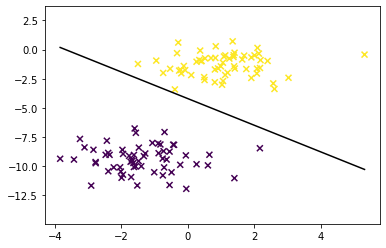

In [ ]:
#Linear model -> f(w,b) = wT * x + b (w = weigths and b is bias)
#Activation function: Unit step function -> g(x) = 1 if x >= 0 and is 0 otherwise.
#We should consider the updates like we learn them in slides. (Consider each training samples.)
import numpy as np
class Perceptron:
  def __init__(self, LearningRate = 0.01 , nIter = 1000):
    self.lr = LearningRate
    self.nIter = nIter
    self.ActivationFunction = self.UnitStepFunction
    self.Weights = None
    self.Bias = None

  def UnitStepFunction (self , x):
    return np.where(x >= 0 , 1 , 0)  #like if x >= 0 so return 1

  def Fit(self , X , y):
    nSamples , nFeatures = X.shape
    #Init Weights
    self.Weights = np.zeros(nFeatures)
    self.Bias = 0
    y_ = np.array([1 if i > 0 else 0 for i in y ])
    for _ in range(self.nIter):
      for Index , x_i in enumerate(X):  #Give the index and current samples
        LinearOutput = np.dot(x_i , self.Weights) + self.Bias
        yPredicted = self.ActivationFunction(LinearOutput)
        Update = self.lr * (y_[Index] - yPredicted)
        self.Weights += Update * x_i
        self.Bias += Update

  def Predict(self , X):
    LinearOutput = np.dot(X , self.Weights) + self.Bias
    yPredicted = self.ActivationFunction(LinearOutput)
    return yPredicted

#Now is time to test
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import datasets
if __name__ == "__main__":
    def Accuracy(y_true, y_pred):
        accuracy = np.sum(y_true == y_pred) / len(y_true)
        return accuracy
    X, y = datasets.make_blobs(n_samples = 150, n_features = 2, centers = 2, cluster_std = 1.05, random_state = 2)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 123)
    p = Perceptron(LearningRate = 0.01 , nIter = 1000)
    p.Fit(X_train, y_train)
    Predictions = p.Predict(X_test)
    print("Perceptron Accuracy: ", Accuracy(y_test, Predictions))
    print("")
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    plt.scatter(X_train[:, 0], X_train[:, 1], marker = "x", c = y_train)
    x0_1 = np.amin(X_train[:, 0])
    x0_2 = np.amax(X_train[:, 0])
    x1_1 = (-p.Weights[0] * x0_1 - p.Bias) / p.Weights[1]
    x1_2 = (-p.Weights[0] * x0_2 - p.Bias) / p.Weights[1]
    ax.plot([x0_1, x0_2], [x1_1, x1_2], "k")
    ymin = np.amin(X_train[:, 1])
    ymax = np.amax(X_train[:, 1])
    ax.set_ylim([ymin - 3, ymax + 3])
    plt.show()